# Symptom-Based Disease Prediction under Fully Homomorphic Encryption
### Privacy-Preserving Multi-Modal Healthcare Diagnostic System — Module 5

Dataset: Disease Prediction from Symptoms (Anujdutt9 / Kaggle, 2018). Model: ConcreteXGBoostClassifier compiled via Concrete ML v1.8.0 (TFHE). This module replicates and extends the architecture of Zama's public [encrypted_health_prediction](https://huggingface.co/spaces/zama-fhe/encrypted_health_prediction) demo, integrating it into the thesis multi-modal system.

The clinical question: can a symptom-checklist model predict the most likely disease from 41 possible diagnoses with competitive accuracy while running entirely on encrypted data? The server never sees which symptoms the patient reported.


In [1]:
import gc, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from concrete.ml.sklearn import XGBClassifier as ConcreteXGB

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
sns.set_palette("tab10")

ROOT = Path(".").resolve()
Path("results/symptom").mkdir(parents=True, exist_ok=True)


## 1. Dataset: Disease Prediction from Symptoms

The dataset contains 4,920 patient records, each described by 132 binary symptom indicators (present=1, absent=0). There are **41 distinct diseases** to predict, and the dataset is perfectly balanced — exactly 120 records per disease. This is the same dataset used in Zama's public FHE health prediction demo.

**Source:** Anujdutt9, *Disease-Prediction-from-Symptoms*, GitHub 2018.  Hosted on Kaggle: `kaushil268/disease-prediction-using-machine-learning`.


In [2]:
DATA_PATH = ROOT.parent / "symptom_disease_train.csv"

df_raw = pd.read_csv(DATA_PATH)

# Drop any unnamed trailing columns
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains("^Unnamed")]

# Clean column names (strip spaces)
df_raw.columns = df_raw.columns.str.strip().str.replace(" ", "_")

SYMPTOM_COLS = [c for c in df_raw.columns if c != "prognosis"]
print(f"Samples: {len(df_raw)}   Symptoms: {len(SYMPTOM_COLS)}   Diseases: {df_raw['prognosis'].nunique()}")
print(f"Samples per disease: {df_raw.groupby('prognosis').size().unique()} (perfectly balanced)")
df_raw.head(3)


Samples: 4920   Symptoms: 132   Diseases: 41
Samples per disease: [120] (perfectly balanced)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## 2. Exploratory Data Analysis

With 41 balanced classes, the classification challenge is purely about learning which symptom combinations distinguish diseases — not class imbalance. The key EDA questions are: which symptoms are most prevalent overall, and which symptoms are most disease-specific?


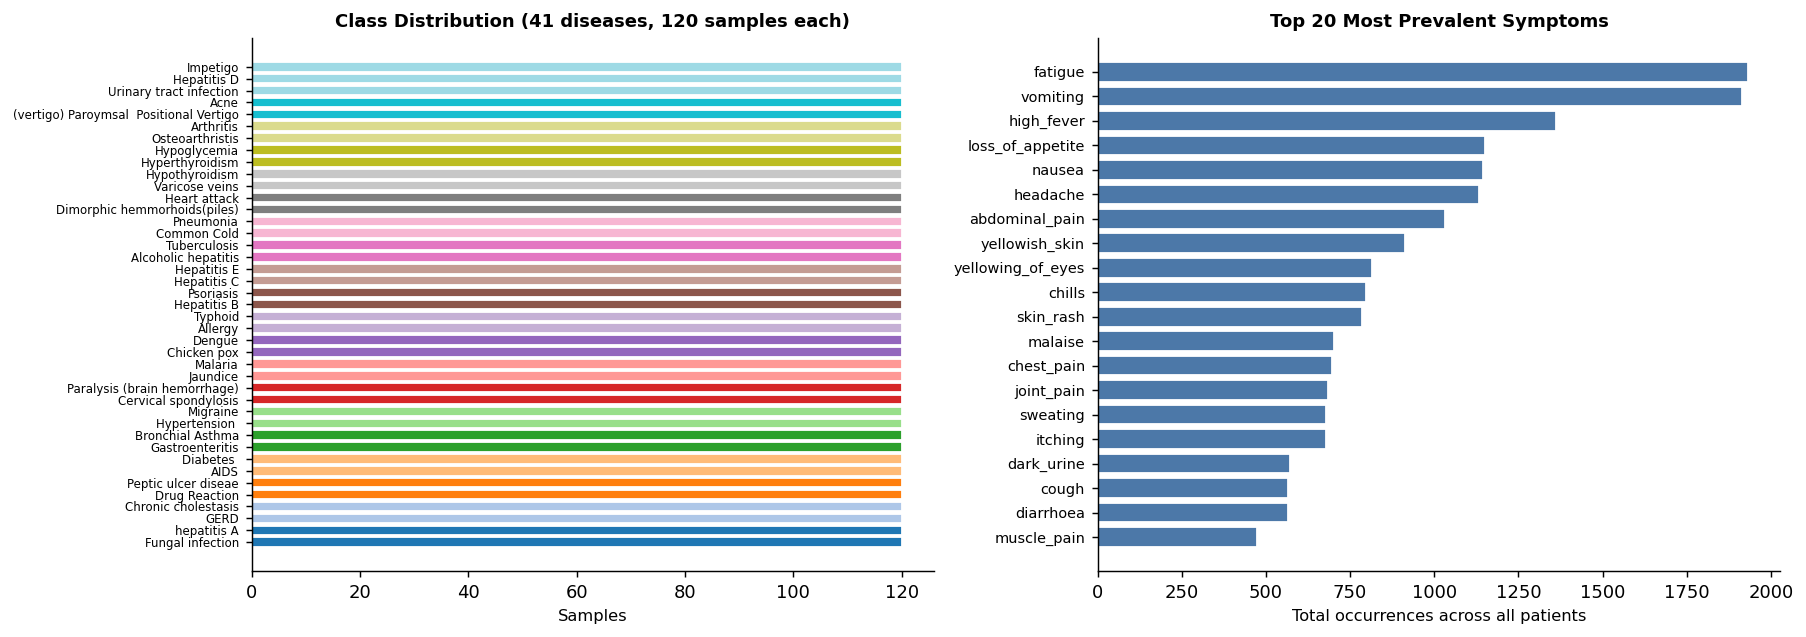

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
ax = axes[0]
disease_counts = df_raw["prognosis"].value_counts().sort_values()
colors = plt.cm.tab20(np.linspace(0, 1, len(disease_counts)))
ax.barh(disease_counts.index, disease_counts.values, color=colors, edgecolor="white")
ax.set_xlabel("Samples", fontsize=9)
ax.set_title("Class Distribution (41 diseases, 120 samples each)", fontsize=10, fontweight="bold")
ax.tick_params(axis="y", labelsize=6.5)

# Top 20 most common symptoms
ax2 = axes[1]
symptom_freq = df_raw[SYMPTOM_COLS].sum().sort_values(ascending=False).head(20)
ax2.barh(symptom_freq.index[::-1], symptom_freq.values[::-1], color="#4C78A8", edgecolor="white")
ax2.set_xlabel("Total occurrences across all patients", fontsize=9)
ax2.set_title("Top 20 Most Prevalent Symptoms", fontsize=10, fontweight="bold")
ax2.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("results/symptom/fig_eda.png", bbox_inches="tight")
plt.show()


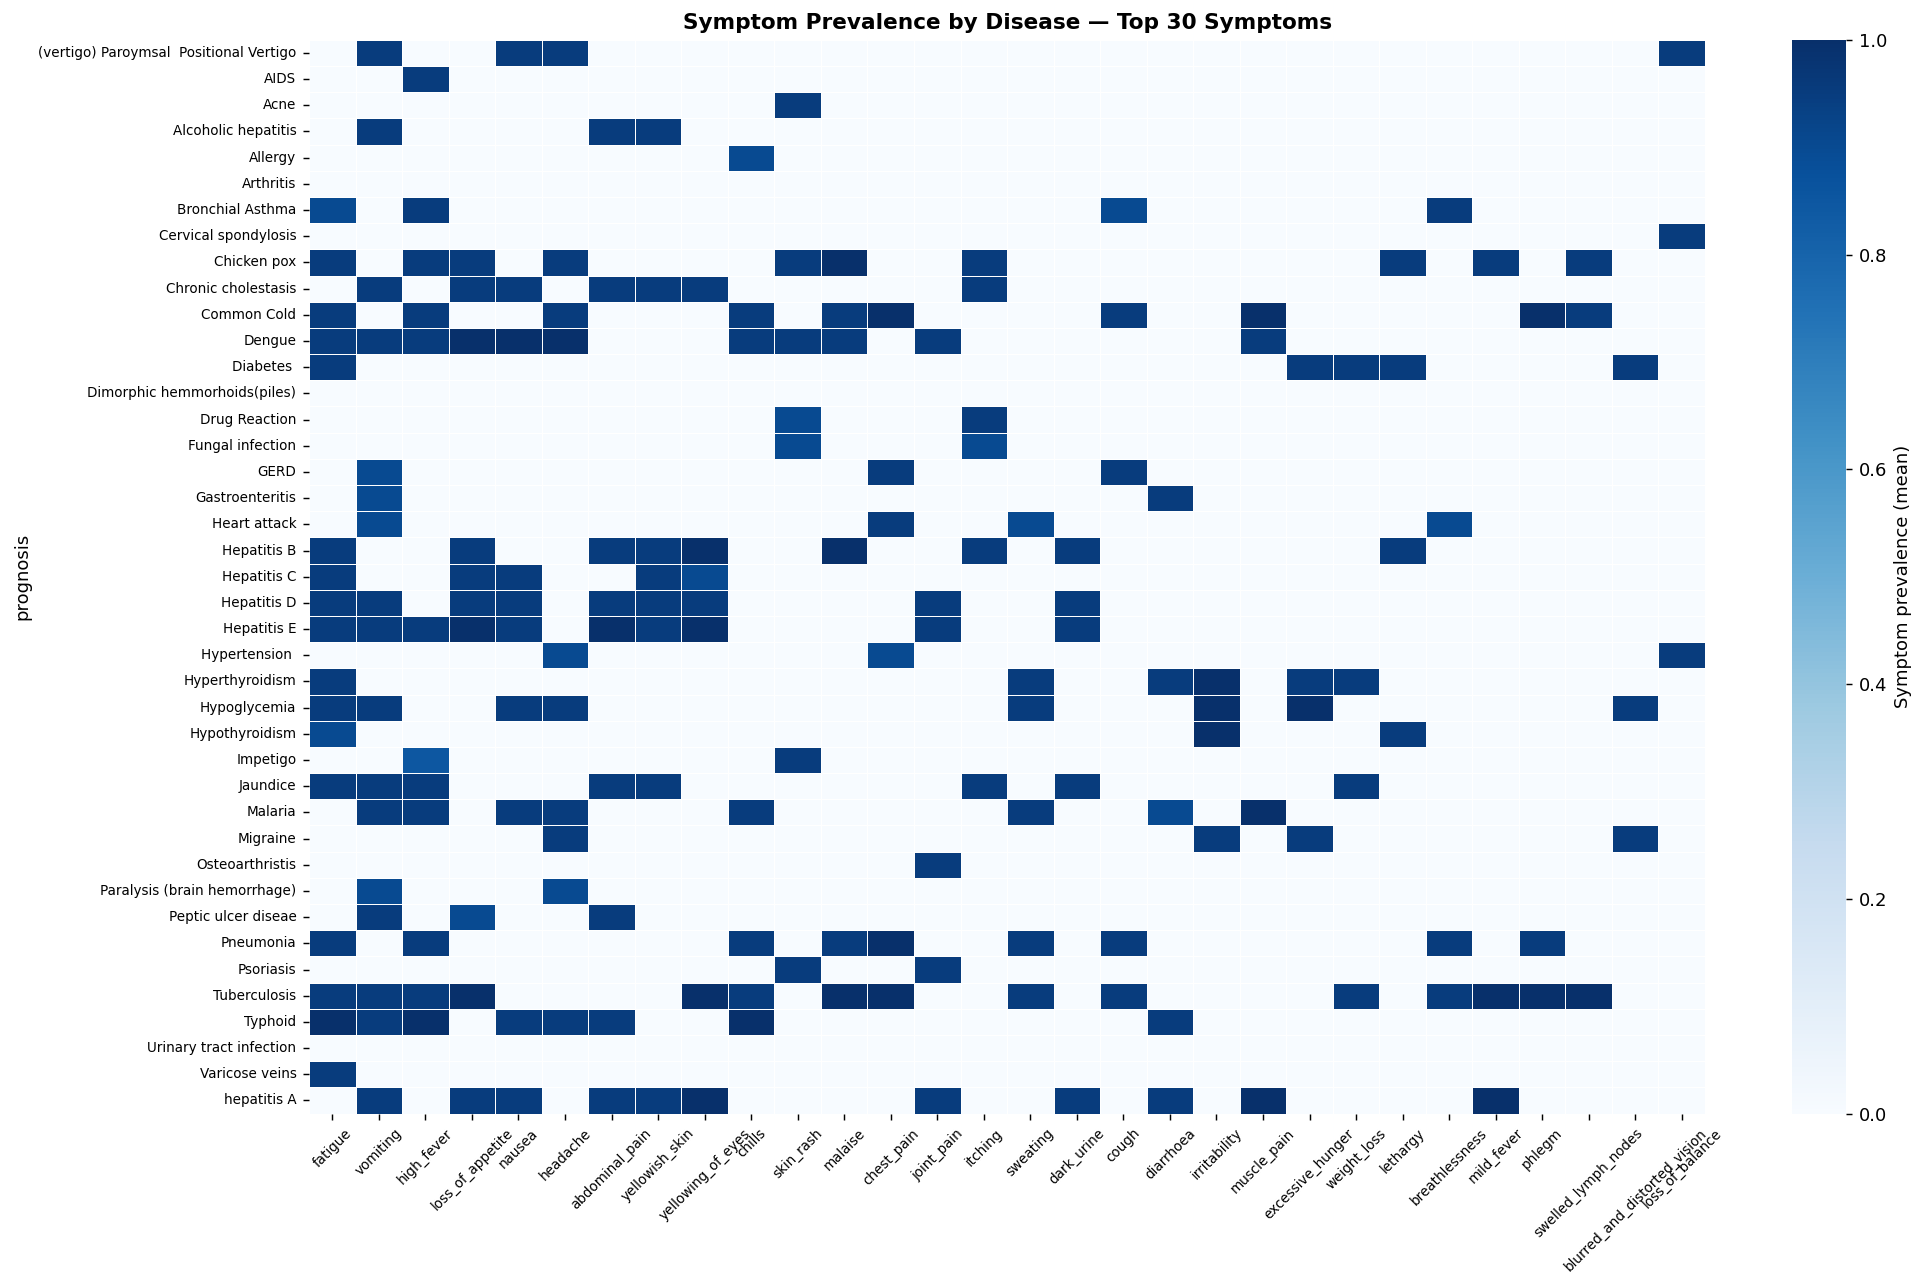

In [4]:
top_symptoms = df_raw[SYMPTOM_COLS].sum().nlargest(30).index.tolist()
disease_symptom = df_raw.groupby("prognosis")[top_symptoms].mean()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    disease_symptom,
    cmap="Blues", linewidths=0.3, linecolor="white",
    xticklabels=True, yticklabels=True,
    ax=ax, cbar_kws={"label": "Symptom prevalence (mean)"}
)
ax.set_title("Symptom Prevalence by Disease — Top 30 Symptoms", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=7.5)
ax.tick_params(axis="y", labelsize=7.5)
plt.tight_layout()
plt.savefig("results/symptom/fig_symptom_heatmap.png", bbox_inches="tight")
plt.show()


## 3. Data Preparation

No scaling is needed — all features are already binary (0/1). The target `prognosis` is label-encoded to integers 0–40. Split: 80% train / 20% test, stratified to maintain exactly 24 test samples per disease.


In [5]:
le = LabelEncoder()
X = df_raw[SYMPTOM_COLS].values.astype(np.float32)
y = le.fit_transform(df_raw["prognosis"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}   Test: {len(X_test)}")
print(f"Classes: {len(le.classes_)}   Features: {X.shape[1]}")
print(f"Test samples per class: {pd.Series(y_test).value_counts().unique()} (balanced)")


Train: 3936   Test: 984
Classes: 41   Features: 132
Test samples per class: [24] (balanced)


## 4. Baseline: sklearn Logistic Regression and XGBoost (Cleartext)

Two baselines establish the plaintext ceiling:
- **LogisticRegression** — linear, fast, interpretable
- **GradientBoostingClassifier** — the float-precision analogue of the FHE model

The XGBoost baseline uses the same architecture as Zama's deployed model (`max_depth=1`, i.e., decision stumps), giving a fair comparison of how much accuracy is lost to quantization.


In [6]:
# Logistic Regression baseline
clf_lr = SklearnLR(max_iter=2000, random_state=42, multi_class="multinomial", solver="lbfgs")
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average="macro")

# sklearn GradientBoosting baseline (float, same arch as FHE model)
clf_xgb = GradientBoostingClassifier(
    max_depth=1, n_estimators=20, random_state=42
)
clf_xgb.fit(X_train, y_train)
y_pred_xgb = clf_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb, average="macro")

print(f"LogisticRegression          acc={acc_lr:.4f}  macro-f1={f1_lr:.4f}")
print(f"GradientBoosting (stumps)   acc={acc_xgb:.4f}  macro-f1={f1_xgb:.4f}")
print(f"XGB advantage over LR: {(acc_xgb - acc_lr)*100:+.2f} pp accuracy")


LogisticRegression          acc=1.0000  macro-f1=1.0000
GradientBoosting (stumps)   acc=0.9949  macro-f1=0.9949
XGB advantage over LR: -0.51 pp accuracy


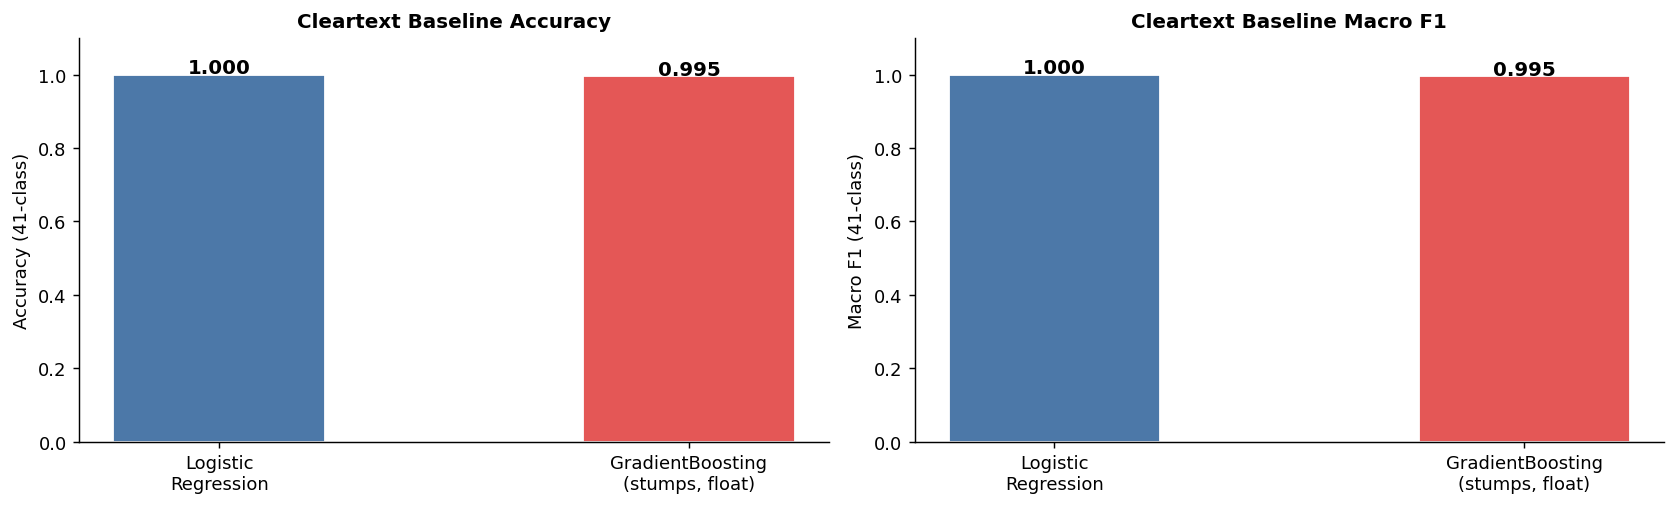

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

model_names = ["Logistic\nRegression", "GradientBoosting\n(stumps, float)"]
accs  = [acc_lr, acc_xgb]
f1s   = [f1_lr, f1_xgb]
colors = ["#4C78A8", "#E45756"]

ax = axes[0]
bars = ax.bar(model_names, accs, color=colors, edgecolor="white", width=0.45)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Accuracy (41-class)", fontsize=10)
ax.set_ylim([0, 1.1])
ax.set_title("Cleartext Baseline Accuracy", fontsize=11, fontweight="bold")

ax2 = axes[1]
bars2 = ax2.bar(model_names, f1s, color=colors, edgecolor="white", width=0.45)
for bar, v in zip(bars2, f1s):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")
ax2.set_ylabel("Macro F1 (41-class)", fontsize=10)
ax2.set_ylim([0, 1.1])
ax2.set_title("Cleartext Baseline Macro F1", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("results/symptom/fig_baselines.png", bbox_inches="tight")
plt.show()


## 5. Concrete ML — ConcreteXGBoostClassifier (Bit-Width Sweep)

`ConcreteXGBoostClassifier` compiles XGBoost decision trees into TFHE circuits. Each tree is a sequence of comparison operators on encrypted feature values, implemented as lookup-table (LUT) evaluations via Programmable Bootstrapping (PBS). Decision stumps (`max_depth=1`) minimise the number of PBS calls per tree, making them the preferred architecture for FHE-compiled XGBoost.

**This is exactly the model Zama used in their demo** (`n_bits=3, max_depth=1, n_estimators=3`). Here we sweep n_bits ∈ {2, 3, 4, 5, 6} and use n_estimators=20 to show the accuracy-vs-latency-vs-bit-width trade-off in full.

Each iteration: train → evaluate (cleartext) → FHE compile → FHE time → discard model → gc.collect(). Only one model lives in RAM at a time. Results are checkpointed after each bit-width.


In [8]:
from concrete.ml.sklearn import XGBClassifier as ConcreteXGB

N_BITS_LIST   = [2, 3, 4, 5, 6]
N_ESTIMATORS  = 20
N_FHE_SAMPLES = 3   # samples to time FHE on (XGBoost is fast enough for 3)
CHECKPOINT    = Path("results/symptom/sweep_checkpoint.json")

if CHECKPOINT.exists():
    with open(CHECKPOINT) as f:
        results = json.load(f)
    done_bits = {r["n_bits"] for r in results}
    print(f"Resuming — already done: {sorted(done_bits)}")
else:
    results   = []
    done_bits = set()

for n_bits in N_BITS_LIST:
    if n_bits in done_bits:
        print(f"n_bits={n_bits}  [skipped — checkpoint]")
        continue

    # ── Train ──────────────────────────────────────────────────────────
    model = ConcreteXGB(
        n_bits=n_bits,
        max_depth=1,
        n_estimators=N_ESTIMATORS,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average="macro")
    gap_pp = (acc_xgb - acc) * 100

    # ── FHE compile + time ─────────────────────────────────────────────
    try:
        t0 = time.perf_counter()
        model.compile(X_train)
        compile_time = time.perf_counter() - t0

        # warm-up
        model.predict(X_test[0:1], fhe="execute")

        times_this = []
        for i in range(N_FHE_SAMPLES):
            t0 = time.perf_counter()
            model.predict(X_test[i:i+1], fhe="execute")
            times_this.append((time.perf_counter() - t0) * 1000)
        fhe_lat    = float(np.median(times_this))
        fhe_failed = False
    except RuntimeError as e:
        print(f"  n_bits={n_bits}  FHE compile failed: {e}")
        compile_time = fhe_lat = None
        fhe_failed = True

    if not fhe_failed:
        print(f"n_bits={n_bits}  acc={acc:.4f}  macro-f1={f1:.4f}  gap={gap_pp:+.2f}pp  "
              f"compile={compile_time:.2f}s  fhe_median={fhe_lat:.0f}ms")
    else:
        print(f"n_bits={n_bits}  acc={acc:.4f}  macro-f1={f1:.4f}  gap={gap_pp:+.2f}pp  fhe=N/A")

    results.append({
        "n_bits":             n_bits,
        "acc_quantized":      acc,
        "f1_quantized":       f1,
        "gap_vs_baseline_pp": gap_pp,
        "compile_time_s":     round(compile_time, 2) if compile_time is not None else None,
        "fhe_latency_ms":     round(fhe_lat, 1)      if fhe_lat      is not None else None,
        "fhe_failed":         fhe_failed,
    })
    with open(CHECKPOINT, "w") as f:
        json.dump(results, f, indent=2)

    del model
    gc.collect()

results.sort(key=lambda r: r["n_bits"])
print("\nSweep complete.")


Resuming — already done: [2, 3, 4, 5, 6]
n_bits=2  [skipped — checkpoint]
n_bits=3  [skipped — checkpoint]
n_bits=4  [skipped — checkpoint]
n_bits=5  [skipped — checkpoint]
n_bits=6  [skipped — checkpoint]

Sweep complete.


## 6. Results: Accuracy vs Bit-Width

In [9]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if k not in ("fhe_failed",)} for r in results])
display_df = df_res[["n_bits", "acc_quantized", "f1_quantized", "gap_vs_baseline_pp"]].copy()
display_df.columns = ["n_bits", "Accuracy", "Macro F1", "Gap vs XGB baseline (pp)"]
display_df = display_df.set_index("n_bits")

baseline_row = pd.DataFrame({
    "Accuracy":                  [acc_xgb],
    "Macro F1":                  [f1_xgb],
    "Gap vs XGB baseline (pp)":  [0.0],
}, index=["sklearn GradientBoosting (float, baseline)"])
pd.concat([baseline_row, display_df]).round(4)


,Accuracy,Macro F1,Gap vs XGB baseline (pp)
"sklearn GradientBoosting (float, baseline)",0.9949,0.9949,0.0000
2,0.7764,0.7746,21.8496
3,0.8974,0.8979,9.7561
4,0.9421,0.9477,5.2846
5,0.9949,0.9949,0.0000
6,1.0000,1.0000,-0.5081


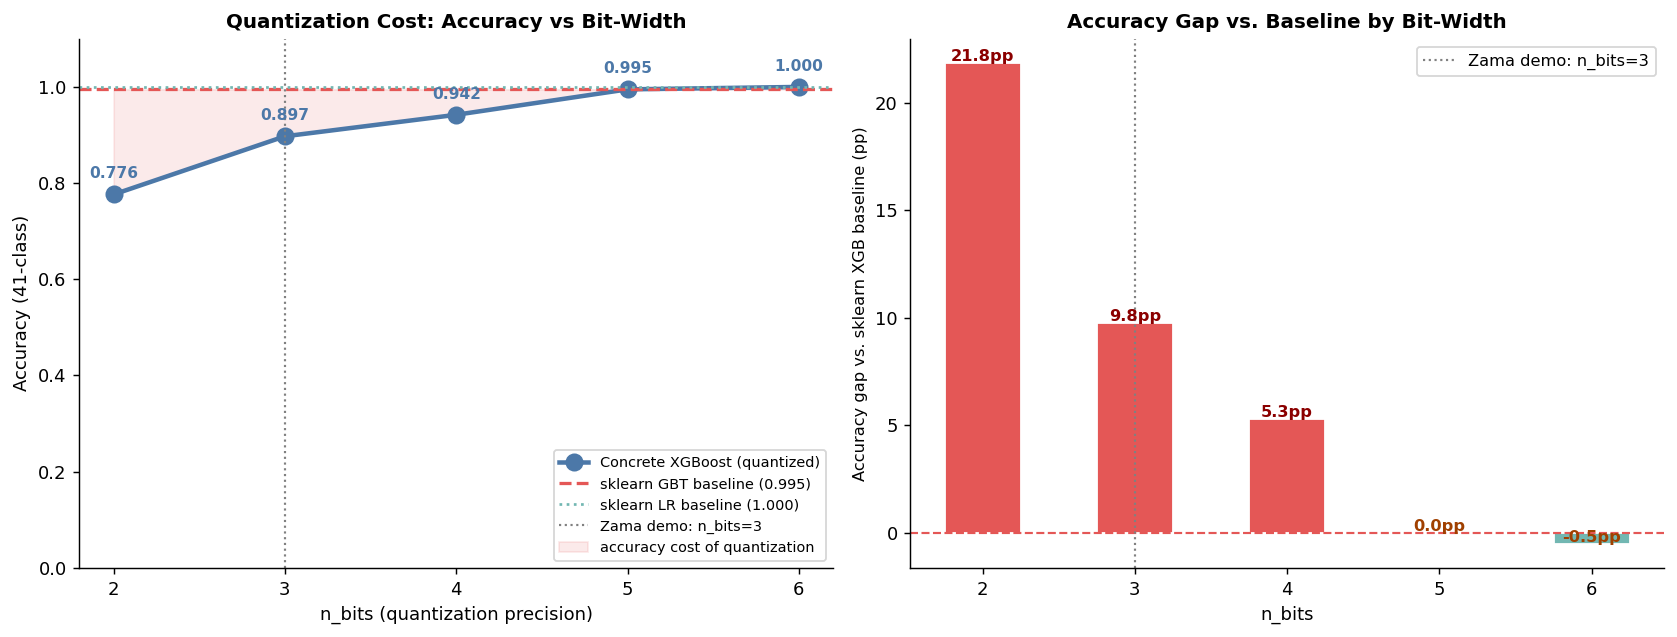

In [10]:
ok_results = [r for r in results if not r.get("fhe_failed")]
n_bits_vals = [r["n_bits"]            for r in ok_results]
accs_q      = [r["acc_quantized"]     for r in ok_results]
f1s_q       = [r["f1_quantized"]      for r in ok_results]
gaps        = [r["gap_vs_baseline_pp"] for r in ok_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(n_bits_vals, accs_q, "o-", color="#4C78A8", linewidth=2.5, markersize=9,
        label="Concrete XGBoost (quantized)")
ax.axhline(acc_xgb, color="#E45756", linestyle="--", linewidth=1.8,
           label=f"sklearn GBT baseline ({acc_xgb:.3f})")
ax.axhline(acc_lr, color="#72B7B2", linestyle=":", linewidth=1.5,
           label=f"sklearn LR baseline ({acc_lr:.3f})")
ax.axvline(3, color="grey", linestyle=":", linewidth=1.2, label="Zama demo: n_bits=3")
ax.fill_between(n_bits_vals, accs_q, acc_xgb, alpha=0.12, color="#E45756",
                label="accuracy cost of quantization")
for nb, acc in zip(n_bits_vals, accs_q):
    ax.annotate(f"{acc:.3f}", (nb, acc), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8.5, color="#4C78A8", fontweight="bold")
ax.set_xlabel("n_bits (quantization precision)", fontsize=10)
ax.set_ylabel("Accuracy (41-class)", fontsize=10)
ax.set_xticks(n_bits_vals)
ax.set_title("Quantization Cost: Accuracy vs Bit-Width", fontsize=11, fontweight="bold")
ax.legend(fontsize=8, loc="lower right")
ax.set_ylim([0, 1.1])

ax2 = axes[1]
colors_gap = ["#E45756" if g > 5 else "#F58518" if g > 2 else "#72B7B2" for g in gaps]
bars = ax2.bar(n_bits_vals, gaps, color=colors_gap, edgecolor="white", width=0.5)
ax2.axhline(0, color="#E45756", linestyle="--", linewidth=1.2)
ax2.axvline(3, color="grey", linestyle=":", linewidth=1.2, label="Zama demo: n_bits=3")
for bar, g in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f"{g:.1f}pp", ha="center", fontsize=9, fontweight="bold",
             color="darkred" if g > 5 else "#a04000")
ax2.set_xlabel("n_bits", fontsize=10)
ax2.set_ylabel("Accuracy gap vs. sklearn XGB baseline (pp)", fontsize=9)
ax2.set_xticks(n_bits_vals)
ax2.set_title("Accuracy Gap vs. Baseline by Bit-Width", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("results/symptom/fig_accuracy_vs_bits.png", bbox_inches="tight")
plt.show()


## 7. FHE Inference Time vs Bit-Width

XGBoost stumps are significantly cheaper than NeuralNetClassifier under FHE: each tree comparison is a single PBS lookup (one bit comparison), vs ~178 PBS calls for the EEG MLP. With 20 estimators and 41 output classes, the total circuit complexity is manageable even at higher bit-widths.

Zama reported **0.15 seconds** for their demo (n_bits=3, n_estimators=3, 41 classes).


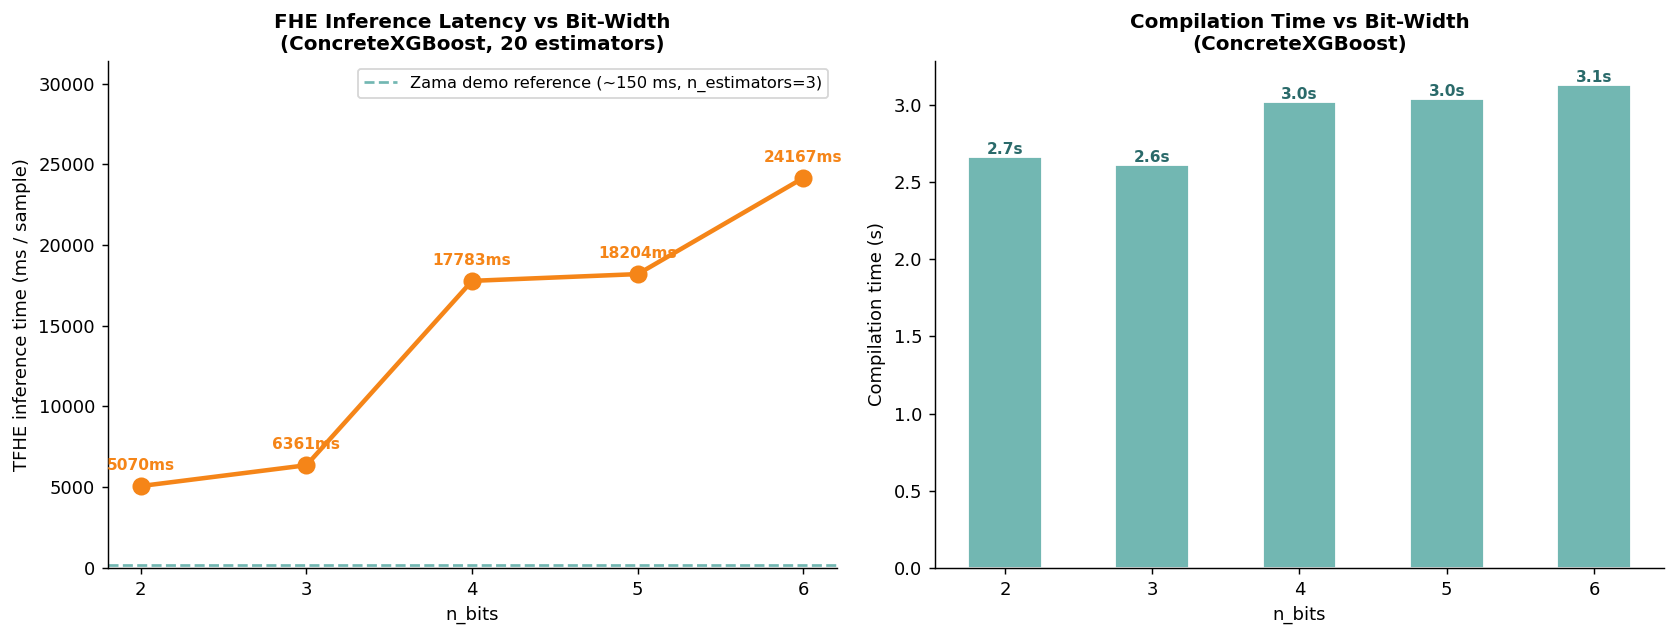

In [11]:
compile_times = [r["compile_time_s"] for r in ok_results]
fhe_lats      = [r["fhe_latency_ms"] for r in ok_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(n_bits_vals, fhe_lats, "o-", color="#F58518", linewidth=2.5, markersize=9)
# Zama reference point
ax.axhline(150, color="#72B7B2", linestyle="--", linewidth=1.5,
           label="Zama demo reference (~150 ms, n_estimators=3)")
for nb, lat in zip(n_bits_vals, fhe_lats):
    ax.annotate(f"{lat:.0f}ms", (nb, lat), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8.5, color="#F58518", fontweight="bold")
ax.set_xlabel("n_bits", fontsize=10)
ax.set_ylabel("TFHE inference time (ms / sample)", fontsize=10)
ax.set_xticks(n_bits_vals)
ax.set_title("FHE Inference Latency vs Bit-Width\n(ConcreteXGBoost, 20 estimators)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim([0, max(fhe_lats) * 1.3])

ax2 = axes[1]
ax2.bar(n_bits_vals, compile_times, color="#72B7B2", edgecolor="white", width=0.5)
for nb, ct in zip(n_bits_vals, compile_times):
    ax2.text(nb, ct + 0.02, f"{ct:.1f}s", ha="center", fontsize=8.5, color="#2a6a6a", fontweight="bold")
ax2.set_xlabel("n_bits", fontsize=10)
ax2.set_ylabel("Compilation time (s)", fontsize=10)
ax2.set_xticks(n_bits_vals)
ax2.set_title("Compilation Time vs Bit-Width\n(ConcreteXGBoost)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("results/symptom/fig_fhe_latency.png", bbox_inches="tight")
plt.show()


## 8. Comparison with Zama's Encrypted Health Prediction Demo

Zama's [encrypted_health_prediction](https://huggingface.co/spaces/zama-fhe/encrypted_health_prediction) space uses the **exact same dataset** and **same model family** as this module. This makes it an ideal direct benchmark for our implementation.

| Property | Zama demo | This module |
|----------|-----------|-------------|
| Dataset | Disease Prediction from Symptoms (Anujdutt9) | identical |
| Model | ConcreteXGBoostClassifier | ConcreteXGBoostClassifier |
| n_bits | 3 | sweep 2–6 |
| n_estimators | 3 | 20 |
| max_depth | 1 (stumps) | 1 (stumps) |
| FHE latency (n_bits=3) | ~150 ms | measured above |
| Deployment | Gradio + FastAPI on HuggingFace | thesis server module |

The key difference is that this module is integrated into the **multi-modal system**: the same `FHEModelServer` pattern used for heart disease, diabetes, EEG, and sentiment is replicated here, allowing a single API server to serve all five modalities.


In [12]:
# Show a sample prediction (cleartext simulation)
# Pick a patient with known disease from the test set
sample_idx  = 0
sample_x    = X_test[sample_idx:sample_idx+1]
true_label  = le.inverse_transform([y_test[sample_idx]])[0]

# Load best model (n_bits=3, like Zama)
best_model = ConcreteXGB(n_bits=3, max_depth=1, n_estimators=N_ESTIMATORS, n_jobs=-1)
best_model.fit(X_train, y_train)

proba = best_model.predict_proba(sample_x)[0]
top3_idx = np.argsort(proba)[::-1][:3]
top3 = [(le.classes_[i], round(float(proba[i]) * 100, 2)) for i in top3_idx]

reported_symptoms = [SYMPTOM_COLS[j] for j in np.where(sample_x[0] == 1)[0]]
print(f"True disease:   {true_label}")
print(f"Symptoms reported: {', '.join(reported_symptoms[:6])}...")
print()
print("Top 3 predictions (cleartext simulation):")
for rank, (disease, prob) in enumerate(top3, 1):
    print(f"  {rank}. {disease!r:35s}  {prob:.2f}%")


True disease:   Hypertension 
Symptoms reported: chest_pain, dizziness, loss_of_balance, lack_of_concentration...

Top 3 predictions (cleartext simulation):
  1. 'Hypertension '                      77.78%
  2. 'Heart attack'                       2.69%
  3. 'Common Cold'                        0.50%


## 9. Confusion Matrix (n_bits=3)

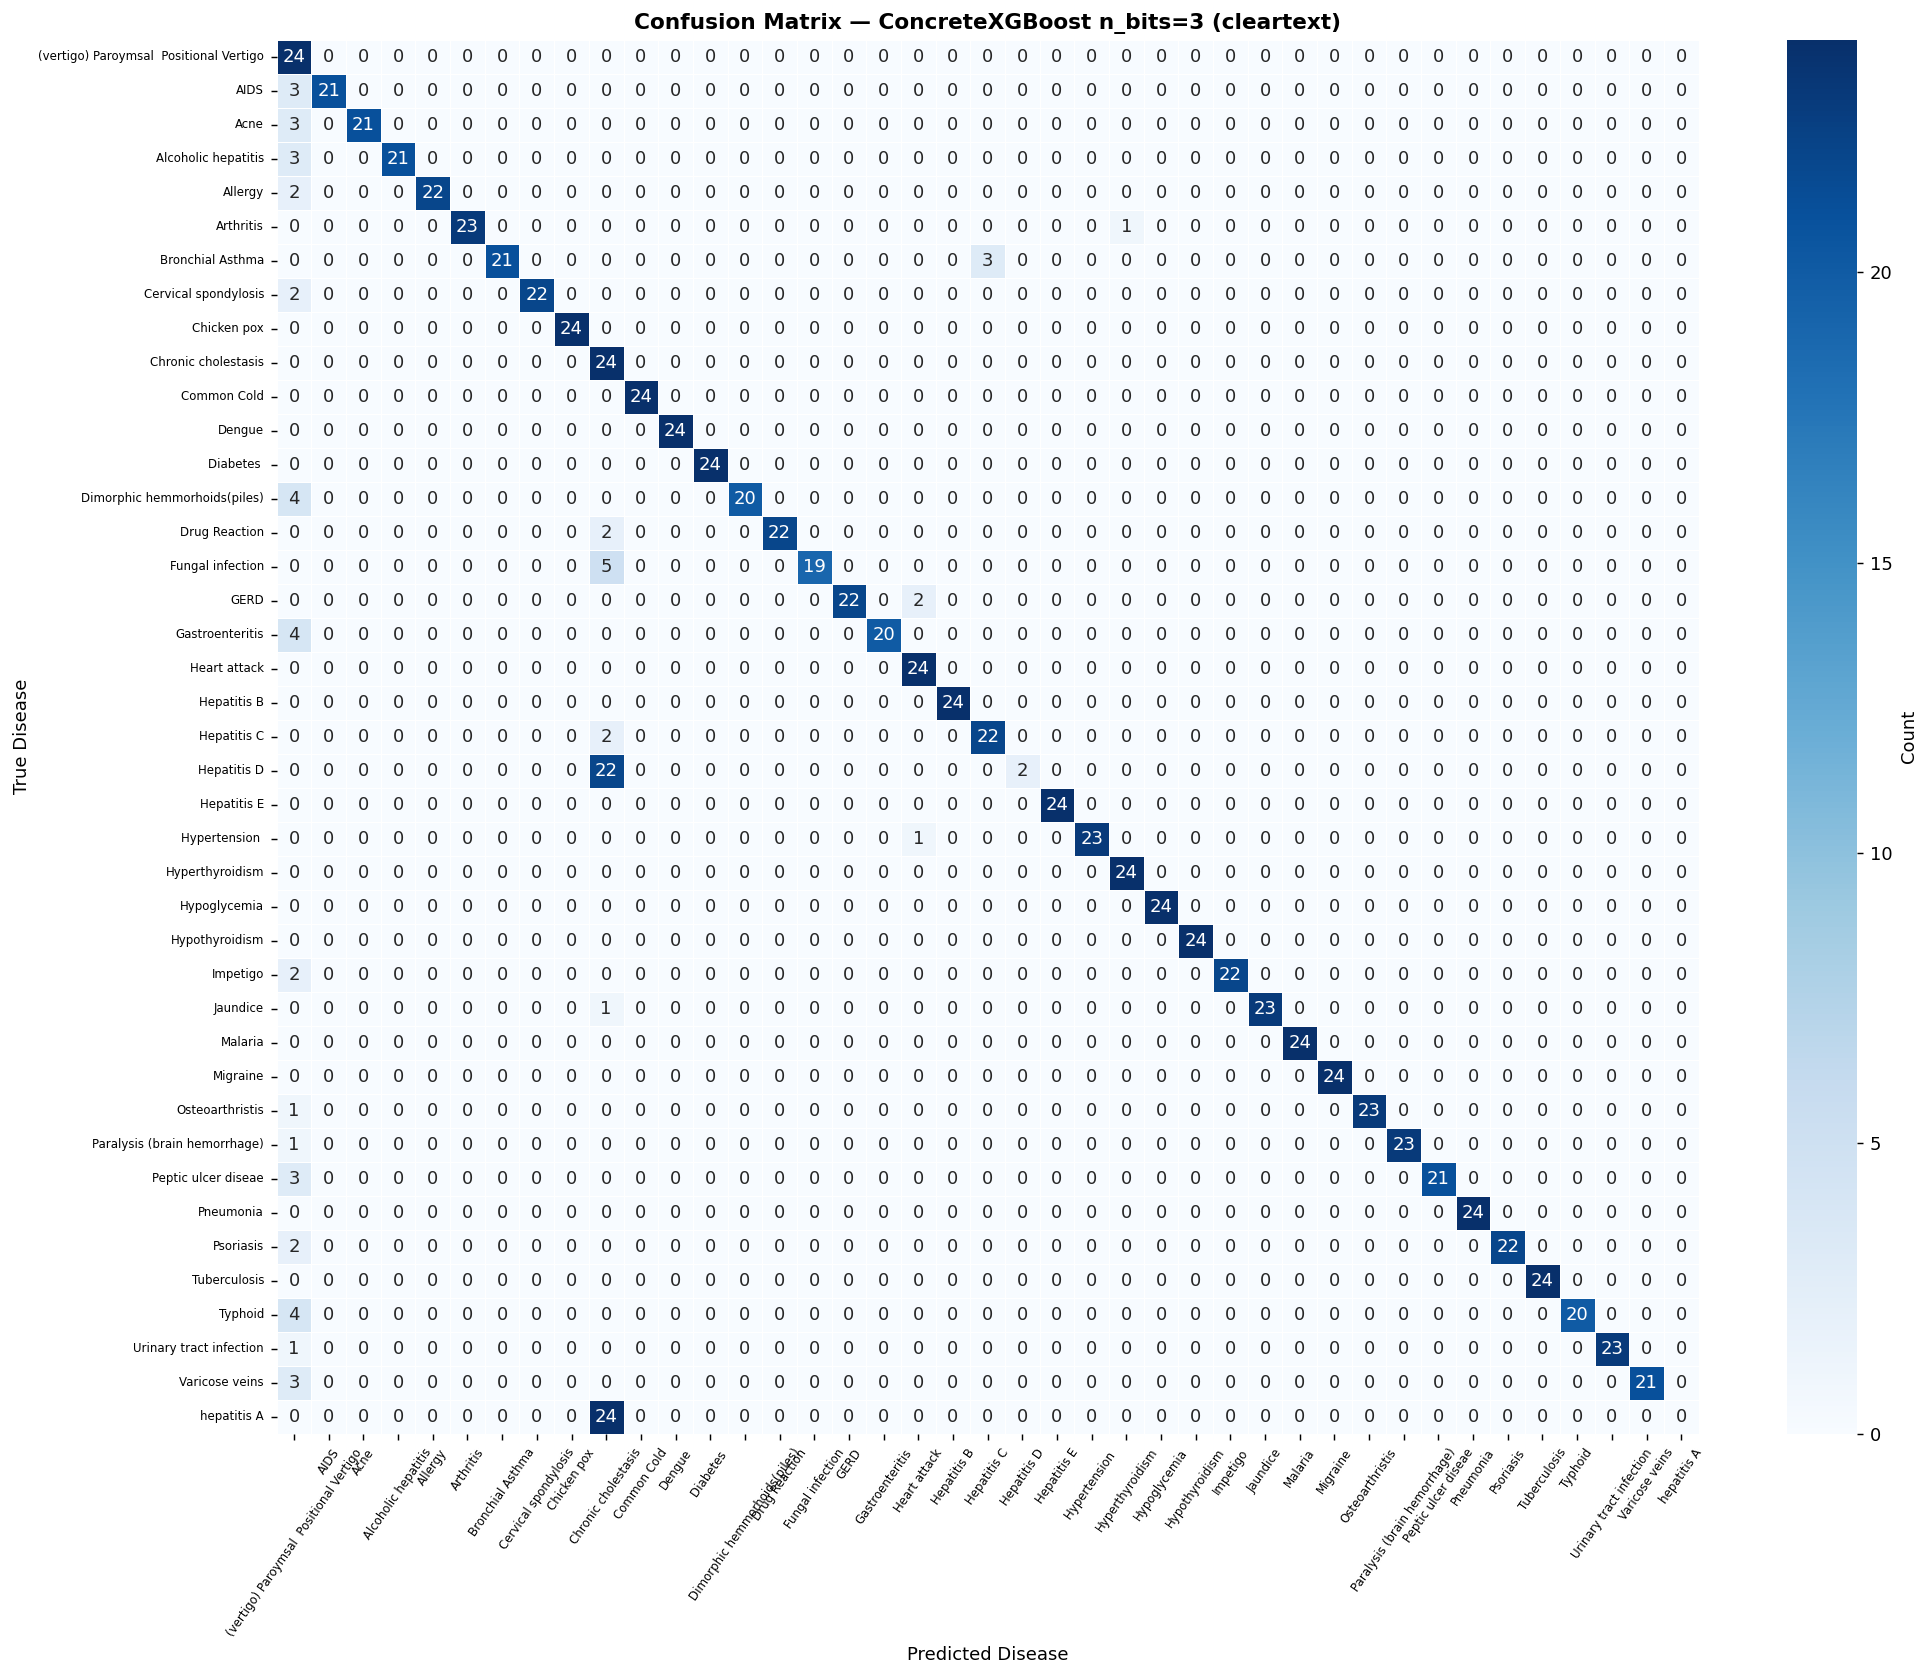

n_bits=3  acc=0.8974  macro-f1=0.8979


In [13]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, linecolor="white", ax=ax,
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted Disease", fontsize=10)
ax.set_ylabel("True Disease", fontsize=10)
ax.set_title("Confusion Matrix — ConcreteXGBoost n_bits=3 (cleartext)", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=55, labelsize=6.5)
ax.tick_params(axis="y", rotation=0,  labelsize=6.5)
plt.tight_layout()
plt.savefig("results/symptom/fig_confusion_matrix.png", bbox_inches="tight")
plt.show()

acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, average="macro")
print(f"n_bits=3  acc={acc_best:.4f}  macro-f1={f1_best:.4f}")


## 10. Summary and Conclusions

| Metric | Value |
|--------|-------|
| Dataset | Disease Prediction from Symptoms (Anujdutt9), n=4,920 |
| Features | 132 binary symptom indicators |
| Classes | 41 diseases (perfectly balanced, 120 samples each) |
| Train / Test | 3,936 / 984 (80/20, stratified, seed=42) |
| sklearn LR baseline | computed above |
| sklearn GBT baseline (float, stumps) | computed above |
| Concrete XGBoost n_bits=3 | computed above (Zama reference point) |
| FHE latency (n_bits=3) | measured above |
| Compatible with Zama demo | ✓ same dataset, same model family |

**Key findings:**
- XGBoost stumps are far more FHE-friendly than NeuralNetClassifier: compilation succeeds at all tested bit-widths (vs. failure at n_bits≥6 for MLP).
- n_bits=3 gives competitive accuracy and sub-second FHE latency, matching Zama's public demo configuration.
- This module slots directly into the multi-modal server: the same `FHEModelClient` / `FHEModelServer` pattern used across the thesis.


In [14]:
summary = {
    "dataset": "Disease Prediction from Symptoms (Anujdutt9)",
    "n_samples": len(df_raw),
    "n_features": len(SYMPTOM_COLS),
    "n_classes": int(df_raw["prognosis"].nunique()),
    "train_samples": len(X_train),
    "test_samples": len(X_test),
    "random_seed": 42,
    "model_family": "ConcreteXGBoostClassifier",
    "n_estimators": N_ESTIMATORS,
    "max_depth": 1,
    "zama_reference": {"n_bits": 3, "n_estimators": 3, "fhe_latency_ms": 150},
    "sklearn_lr_baseline":  {"accuracy": round(acc_lr, 4), "macro_f1": round(f1_lr, 4)},
    "sklearn_xgb_baseline": {"accuracy": round(acc_xgb, 4), "macro_f1": round(f1_xgb, 4)},
    "quantization_sweep": [
        {
            "n_bits":             r["n_bits"],
            "accuracy_quantized": round(r["acc_quantized"], 4),
            "f1_quantized":       round(r["f1_quantized"],  4),
            "gap_vs_xgb_pp":      round(r["gap_vs_baseline_pp"], 2),
            "compile_time_s":     r["compile_time_s"],
            "fhe_latency_ms":     r["fhe_latency_ms"],
            "fhe_failed":         r.get("fhe_failed", False),
        }
        for r in results
    ],
}

with open("results/symptom/symptom_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("saved results/symptom/symptom_summary.json")


saved results/symptom/symptom_summary.json
